In [78]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [79]:
def count_valid_days(file_path, threshold=15):
    """
    Counts the number of days with high and low CGM data coverage based on a specified threshold.

    Parameters:
    ----------
    file_path : str
        The path to the CSV file containing CGM data. The file must have a 'timestamp' column in datetime format.
    threshold : int, optional
        The maximum allowable gap (in minutes) between consecutive readings to cap the time differences. 
        Default is 15 minutes.

    Returns:
    -------
    tuple[int, int]
        A tuple containing:
        - high_coverage_days (int): The number of days with at least 70% CGM data coverage.
        - low_coverage_days (int): The number of days with less than 70% CGM data coverage.
    """
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return 0, 0

    # Skip files with no data (only headers or empty content)
    if df.empty or len(df.columns) < 2:  # Ensure at least 'timestamp', 'BGvalue', and 'date' columns exist
        print(f"Skipping empty or invalid file: {file_path}")
        return 0, 0
    df = pd.read_csv(file_path)
    # Ignore rows that do not follow the regular timestamp format
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    # Extract the date part from the timestamp
    df['date'] = pd.to_datetime(df['timestamp']).dt.date
    # Make sure timestamp is in datetime format
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Group by day
    coverage_list = []

    for date, group in df.groupby(df['timestamp'].dt.date):
        group = group.sort_values('timestamp')
        
        # Compute time differences in minutes between consecutive readings
        time_diffs = group['timestamp'].diff().dt.total_seconds().div(60).dropna()

        # Cap the gap to a max reasonable interval (e.g., 15 min) to avoid overestimating long missing periods
        capped_diffs = np.minimum(time_diffs, threshold)

        # Sum capped diffs to estimate minutes with coverage
        minutes_with_data = capped_diffs.sum()

        # Coverage percent relative to a full 1440-minute day
        coverage_percent = minutes_with_data / 1440 * 100

        coverage_list.append({
            'date': date,
            'num_entries': len(group),
            'minutes_with_data': round(minutes_with_data),
            'coverage_percent': round(coverage_percent)
        })

    # Convert to DataFrame
    coverage_df = pd.DataFrame(coverage_list)

    # Count days with coverage >= 70%
    high_coverage_days = (coverage_df['coverage_percent'] >= 70).sum()

    # Count days with coverage < 70%
    low_coverage_days = (coverage_df['coverage_percent'] < 70).sum()
    return high_coverage_days, low_coverage_days


# OhioT1DM

In [ ]:
# Folder path
# 2018
folder_path_2018_test = '../1_OhioT1DM/2018/test'
folder_path_2018_train = '../1_OhioT1DM/2018/train'
# List all files in the folder
file_names_2018_test = [f for f in os.listdir(folder_path_2018_test) if os.path.isfile(os.path.join(folder_path_2018_test, f))]
file_names_2018_train = [f for f in os.listdir(folder_path_2018_train) if os.path.isfile(os.path.join(folder_path_2018_train, f))]


# 2020
folder_path_2020_test = '../1_OhioT1DM/2020/test'
folder_path_2020_train = '../1_OhioT1DM/2020/train'
file_names_2020_test = [f for f in os.listdir(folder_path_2020_test) if os.path.isfile(os.path.join(folder_path_2020_test, f))]
file_names_2020_train = [f for f in os.listdir(folder_path_2020_train) if os.path.isfile(os.path.join(folder_path_2020_train, f))]


In [38]:
# Initialize a dictionary to hold the unique date counts by subject ID
valid_day_num = 0
invalid_day_num = 0

# Process files in the train folder
for input_file in file_names_2018_train:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2018_train, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=15)
    valid_day_num += valid
    invalid_day_num += invalid

    
# Process files in the test folder
for input_file in file_names_2018_test:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2018_test, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=15)
    valid_day_num += valid
    invalid_day_num += invalid


# Process files in the train folder
for input_file in file_names_2020_train:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2020_train, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=15)
    valid_day_num += valid
    invalid_day_num += invalid

    
# Process files in the test folder
for input_file in file_names_2020_test:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2020_test, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=15)
    valid_day_num += valid
    invalid_day_num += invalid

In [39]:
print(f"Days with ≥ 70% coverage: {valid_day_num}")
print(f"Days with < 70% coverage: {invalid_day_num}")

Days with ≥ 70% coverage: 569
Days with < 70% coverage: 83


In [40]:
print(f"Ratio with ≥ 70% coverage: {valid_day_num/(valid_day_num + invalid_day_num)}")
print(f"Ratio with < 70% coverage: {invalid_day_num/(valid_day_num + invalid_day_num)}")

Ratio with ≥ 70% coverage: 0.8726993865030674
Ratio with < 70% coverage: 0.1273006134969325


# T1DEXI

In [ ]:
folder_path_t1dexi = '../2_T1DEXI/'
file_names_t1dexi= [f for f in os.listdir(folder_path_t1dexi) if os.path.isfile(os.path.join(folder_path_t1dexi, f))]
valid_day_num_t1dexi = 0
invalid_day_num_t1dexi = 0
for input_file in file_names_t1dexi:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_t1dexi, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=15)
    valid_day_num_t1dexi += valid
    invalid_day_num_t1dexi += invalid

Skipping empty or invalid file: ./processed_T1DEXI/1606.csv
Skipping empty or invalid file: ./processed_T1DEXI/323.csv
Skipping empty or invalid file: ./processed_T1DEXI/1093.csv
Skipping empty or invalid file: ./processed_T1DEXI/329.csv
Skipping empty or invalid file: ./processed_T1DEXI/1118.csv


In [30]:
input_file

'1606.csv'

In [52]:
print(f"Days with ≥ 70% coverage: {valid_day_num_t1dexi}")
print(f"Days with < 70% coverage: {invalid_day_num_t1dexi}")

Days with ≥ 70% coverage: 13159
Days with < 70% coverage: 363


In [53]:
print(f"Ratio with ≥ 70% coverage: {valid_day_num_t1dexi / (valid_day_num_t1dexi + invalid_day_num_t1dexi)}")
print(f"Ratio with < 70% coverage: {invalid_day_num_t1dexi / (valid_day_num_t1dexi + invalid_day_num_t1dexi)}")

Ratio with ≥ 70% coverage: 0.9731548587487058
Ratio with < 70% coverage: 0.026845141251294186


# BIG IDEAS LAB

In [ ]:
folder_path_bil = '../4_BIG_IDEA_LAB/'
file_names_bil= [f for f in os.listdir(folder_path_bil) if os.path.isfile(os.path.join(folder_path_bil, f))]
valid_day_num_bil = 0
invalid_day_num_bil = 0
# Process files in the train folder
for input_file in file_names_bil:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_bil, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=15)
    valid_day_num_bil += valid
    invalid_day_num_bil += invalid

In [25]:
print(f"Days with ≥ 70% coverage: {valid_day_num_bil}")
print(f"Days with < 70% coverage: {invalid_day_num_bil}")

Days with ≥ 70% coverage: 115
Days with < 70% coverage: 35


In [26]:
print(f"Ratio with ≥ 70% coverage: {valid_day_num_bil / (valid_day_num_bil + invalid_day_num_bil)}")
print(f"Ratio with < 70% coverage: {invalid_day_num_bil / (valid_day_num_bil + invalid_day_num_bil)}")

Ratio with ≥ 70% coverage: 0.7666666666666667
Ratio with < 70% coverage: 0.23333333333333334


# T1DiabetesGranada

In [ ]:
folder_path_T1DiabetesGranada= '../8_T1DiabetesGranada/'
file_names_T1DiabetesGranada= [f for f in os.listdir(folder_path_T1DiabetesGranada) if os.path.isfile(os.path.join(folder_path_T1DiabetesGranada, f))]
valid_day_num_T1DiabetesGranada = 0
invalid_day_num_T1DiabetesGranada = 0
# Process files in the train folder
for input_file in file_names_T1DiabetesGranada:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_T1DiabetesGranada, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=45)
    valid_day_num_T1DiabetesGranada += valid
    invalid_day_num_T1DiabetesGranada += invalid

In [13]:
print(f"Days with ≥ 70% coverage: {valid_day_num_T1DiabetesGranada}")
print(f"Days with < 70% coverage: {invalid_day_num_T1DiabetesGranada}")

Days with ≥ 70% coverage: 232450
Days with < 70% coverage: 25332


In [14]:
print(f"Ratio with ≥ 70% coverage: {valid_day_num_T1DiabetesGranada / (valid_day_num_T1DiabetesGranada+ invalid_day_num_T1DiabetesGranada)}")
print(f"Ratio with < 70% coverage: {invalid_day_num_T1DiabetesGranada / (valid_day_num_T1DiabetesGranada+ invalid_day_num_T1DiabetesGranada)}")

Ratio with ≥ 70% coverage: 0.9017309199245874
Ratio with < 70% coverage: 0.09826908007541256


# UCHTT1DM

In [ ]:
folder_path_uchtt1dm= '../10_UCHTT1DM/'
file_names_uchtt1dm= [f for f in os.listdir(folder_path_uchtt1dm) if os.path.isfile(os.path.join(folder_path_uchtt1dm, f))]
valid_day_num_uchtt1dm = 0
invalid_day_num_uchtt1dm = 0

# Process files in the train folder
for input_file in file_names_uchtt1dm:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_uchtt1dm, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=15)
    valid_day_num_uchtt1dm += valid
    invalid_day_num_uchtt1dm += invalid

In [16]:
print(f"Days with ≥ 70% coverage: {valid_day_num_uchtt1dm}")
print(f"Days with < 70% coverage: {invalid_day_num_uchtt1dm}")

Days with ≥ 70% coverage: 97
Days with < 70% coverage: 30


In [17]:
print(f"Ratio with ≥ 70% coverage: {valid_day_num_uchtt1dm / (valid_day_num_uchtt1dm+ invalid_day_num_uchtt1dm)}")
print(f"Ratio with < 70% coverage: {invalid_day_num_uchtt1dm / (valid_day_num_uchtt1dm+ invalid_day_num_uchtt1dm)}")

Ratio with ≥ 70% coverage: 0.7637795275590551
Ratio with < 70% coverage: 0.23622047244094488


# DiaTrend

In [ ]:
folder_path_diatrend= '../5_Diatrend/'
file_names_diatrend= [f for f in os.listdir(folder_path_diatrend) if os.path.isfile(os.path.join(folder_path_diatrend, f))]
valid_day_num_diatrend = 0
invalid_day_num_diatrend = 0

# Process files in the train folder
for input_file in file_names_diatrend:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_diatrend, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=15)
    valid_day_num_diatrend += valid
    invalid_day_num_diatrend += invalid

print(f"Days with ≥ 70% coverage: {valid_day_num_diatrend}")
print(f"Days with < 70% coverage: {invalid_day_num_diatrend}")

print(f"Ratio with ≥ 70% coverage: {valid_day_num_diatrend / (valid_day_num_diatrend+ invalid_day_num_diatrend)}")
print(f"Ratio with < 70% coverage: {invalid_day_num_diatrend / (valid_day_num_diatrend+ invalid_day_num_diatrend)}")

Days with ≥ 70% coverage: 24891
Days with < 70% coverage: 2772
Ratio with ≥ 70% coverage: 0.899793948595597
Ratio with < 70% coverage: 0.10020605140440299


# ShanghaiT1DM

In [ ]:
folder_path_shanghait1= '../6_ShanghaiT1DM/'
file_names_shanghait1= [f for f in os.listdir(folder_path_shanghait1) if os.path.isfile(os.path.join(folder_path_shanghait1, f))]
valid_day_num_shanghait1 = 0
invalid_day_num_shanghait1 = 0

# Process files in the train folder
for input_file in file_names_shanghait1:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_shanghait1, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=45)
    valid_day_num_shanghait1 += valid
    invalid_day_num_shanghait1 += invalid

print(f"Days with ≥ 70% coverage: {valid_day_num_shanghait1}")
print(f"Days with < 70% coverage: {invalid_day_num_shanghait1}")

print(f"Ratio with ≥ 70% coverage: {valid_day_num_shanghait1 / (valid_day_num_shanghait1+ invalid_day_num_shanghait1)}")
print(f"Ratio with < 70% coverage: {invalid_day_num_shanghait1 / (valid_day_num_shanghait1+ invalid_day_num_shanghait1)}")

Days with ≥ 70% coverage: 151
Days with < 70% coverage: 30
Ratio with ≥ 70% coverage: 0.8342541436464088
Ratio with < 70% coverage: 0.16574585635359115


# ShanghaiT2DM

In [ ]:
folder_path_shanghait2= '../7_ShanghaiT2DM/'
file_names_shanghait2= [f for f in os.listdir(folder_path_shanghait2) if os.path.isfile(os.path.join(folder_path_shanghait2, f))]
valid_day_num_shanghait2 = 0
invalid_day_num_shanghait2 = 0

# Process files in the train folder
for input_file in file_names_shanghait2:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_shanghait2, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=45)
    valid_day_num_shanghait2 += valid
    invalid_day_num_shanghait2 += invalid

print(f"Days with ≥ 70% coverage: {valid_day_num_shanghait2}")
print(f"Days with < 70% coverage: {invalid_day_num_shanghait2}")

print(f"Ratio with ≥ 70% coverage: {valid_day_num_shanghait2 / (valid_day_num_shanghait2+ invalid_day_num_shanghait2)}")
print(f"Ratio with < 70% coverage: {invalid_day_num_shanghait2 / (valid_day_num_shanghait2+ invalid_day_num_shanghait2)}")

Days with ≥ 70% coverage: 1092
Days with < 70% coverage: 200
Ratio with ≥ 70% coverage: 0.8452012383900929
Ratio with < 70% coverage: 0.15479876160990713


# AI-READI

In [ ]:
folder_path_aireadi= '../9_AI-READI/'
file_names_aireadi= [f for f in os.listdir(folder_path_aireadi) if os.path.isfile(os.path.join(folder_path_aireadi, f))]
valid_day_num_aireadi = 0
invalid_day_num_aireadi = 0

# Process files in the train folder
for input_file in file_names_aireadi:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_aireadi, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=15)
    valid_day_num_aireadi += valid
    invalid_day_num_aireadi += invalid

print(f"Days with ≥ 70% coverage: {valid_day_num_aireadi}")
print(f"Days with < 70% coverage: {invalid_day_num_aireadi}")

print(f"Ratio with ≥ 70% coverage: {valid_day_num_aireadi / (valid_day_num_aireadi+ invalid_day_num_aireadi)}")
print(f"Ratio with < 70% coverage: {invalid_day_num_aireadi / (valid_day_num_aireadi+ invalid_day_num_aireadi)}")

Days with ≥ 70% coverage: 9779
Days with < 70% coverage: 1402
Ratio with ≥ 70% coverage: 0.8746087112065111
Ratio with < 70% coverage: 0.12539128879348896


# CGMacros

In [ ]:
folder_path_CGMacros_dexcom = '../11_CGMacros/Dexcom GL'
file_names_CGMacros_dexcom = [f for f in os.listdir(folder_path_CGMacros_dexcom) if os.path.isfile(os.path.join(folder_path_CGMacros_dexcom, f))]
# folder_path_CGMacros_libre = './11_CGMacros/Libre GL'
# file_names_CGMacros_libre = [f for f in os.listdir(folder_path_CGMacros_libre) if os.path.isfile(os.path.join(folder_path_CGMacros_libre, f))]

valid_day_num_CGMacros = 0
invalid_day_num_CGMacros = 0

# Process files in the train folder
for input_file in file_names_CGMacros_dexcom:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_CGMacros_dexcom, input_file)
    valid, invalid = count_valid_days(full_file_path, threshold=15)
    valid_day_num_CGMacros += valid
    invalid_day_num_CGMacros += invalid

print(f"Days with ≥ 70% coverage: {valid_day_num_CGMacros}")
print(f"Days with < 70% coverage: {invalid_day_num_CGMacros}")

print(f"Ratio with ≥ 70% coverage: {valid_day_num_CGMacros / (valid_day_num_CGMacros+ invalid_day_num_CGMacros)}")
print(f"Ratio with < 70% coverage: {invalid_day_num_CGMacros / (valid_day_num_CGMacros+ invalid_day_num_CGMacros)}")

# valid_day_num_CGMacros = 0
# invalid_day_num_CGMacros = 0
# # Process files in the train folder
# for input_file in file_names_CGMacros_libre:
#     # Parse the CSV file
#     full_file_path = os.path.join(folder_path_CGMacros_libre, input_file)
#     valid, invalid = count_valid_days(full_file_path, threshold=15)
#     valid_day_num_CGMacros += valid
#     invalid_day_num_CGMacros += invalid

# print(f"Days with ≥ 70% coverage: {valid_day_num_CGMacros}")
# print(f"Days with < 70% coverage: {invalid_day_num_CGMacros}")

# print(f"Ratio with ≥ 70% coverage: {valid_day_num_CGMacros / (valid_day_num_CGMacros+ invalid_day_num_CGMacros)}")
# print(f"Ratio with < 70% coverage: {invalid_day_num_CGMacros / (valid_day_num_CGMacros+ invalid_day_num_CGMacros)}")

Days with ≥ 70% coverage: 400
Days with < 70% coverage: 93
Ratio with ≥ 70% coverage: 0.8113590263691683
Ratio with < 70% coverage: 0.18864097363083165


In [117]:
print(f"Days with ≥ 70% coverage: {valid_day_num_CGMacros}")
print(f"Days with < 70% coverage: {invalid_day_num_CGMacros}")

print(f"Ratio with ≥ 70% coverage: {valid_day_num_CGMacros / (valid_day_num_CGMacros+ invalid_day_num_CGMacros)}")
print(f"Ratio with < 70% coverage: {invalid_day_num_CGMacros / (valid_day_num_CGMacros+ invalid_day_num_CGMacros)}")

Days with ≥ 70% coverage: 835
Days with < 70% coverage: 191
Ratio with ≥ 70% coverage: 0.8138401559454191
Ratio with < 70% coverage: 0.1861598440545809


In [54]:
valid_ratio_ohio = valid_day_num / (valid_day_num + invalid_day_num)
invalid_ratio_ohio = invalid_day_num / (valid_day_num + invalid_day_num)
valid_ratio_t1dexi = valid_day_num_t1dexi / (valid_day_num_t1dexi + invalid_day_num_t1dexi)
invalid_ratio_t1dexi = invalid_day_num_t1dexi / (valid_day_num_t1dexi + invalid_day_num_t1dexi)
valid_ratio_bil = valid_day_num_bil / (valid_day_num_bil + invalid_day_num_bil)
invalid_ratio_bil = invalid_day_num_bil / (valid_day_num_bil + invalid_day_num_bil)
valid_ratio_T1DiabetesGranada = valid_day_num_T1DiabetesGranada / (valid_day_num_T1DiabetesGranada + invalid_day_num_T1DiabetesGranada)
invalid_ratio_T1DiabetesGranada = invalid_day_num_T1DiabetesGranada / (valid_day_num_T1DiabetesGranada + invalid_day_num_T1DiabetesGranada)
valid_ratio_uchtt1dm = valid_day_num_uchtt1dm / (valid_day_num_uchtt1dm + invalid_day_num_uchtt1dm)
invalid_ratio_uchtt1dm = invalid_day_num_uchtt1dm / (valid_day_num_uchtt1dm + invalid_day_num_uchtt1dm)


valid_ratio_diatrend = valid_day_num_diatrend / (valid_day_num_diatrend + invalid_day_num_diatrend)
invalid_ratio_diatrend = invalid_day_num_diatrend / (valid_day_num_diatrend + invalid_day_num_diatrend)
valid_ratio_shanghait1 = valid_day_num_shanghait1 / (valid_day_num_shanghait1 + invalid_day_num_shanghait1)
invalid_ratio_shanghait1 = invalid_day_num_shanghait1 / (valid_day_num_shanghait1 + invalid_day_num_shanghait1)
valid_ratio_shanghait2 = valid_day_num_shanghait2 / (valid_day_num_shanghait2 + invalid_day_num_shanghait2)
invalid_ratio_shanghait2 = invalid_day_num_shanghait2 / (valid_day_num_shanghait2 + invalid_day_num_shanghait2)
valid_ratio_aireadi = valid_day_num_aireadi / (valid_day_num_aireadi + invalid_day_num_aireadi)
invalid_ratio_aireadi = invalid_day_num_aireadi / (valid_day_num_aireadi + invalid_day_num_aireadi)
valid_ratio_CGMacros = valid_day_num_CGMacros / (valid_day_num_CGMacros + invalid_day_num_CGMacros)
invalid_ratio_CGMacros = invalid_day_num_CGMacros / (valid_day_num_CGMacros + invalid_day_num_CGMacros)



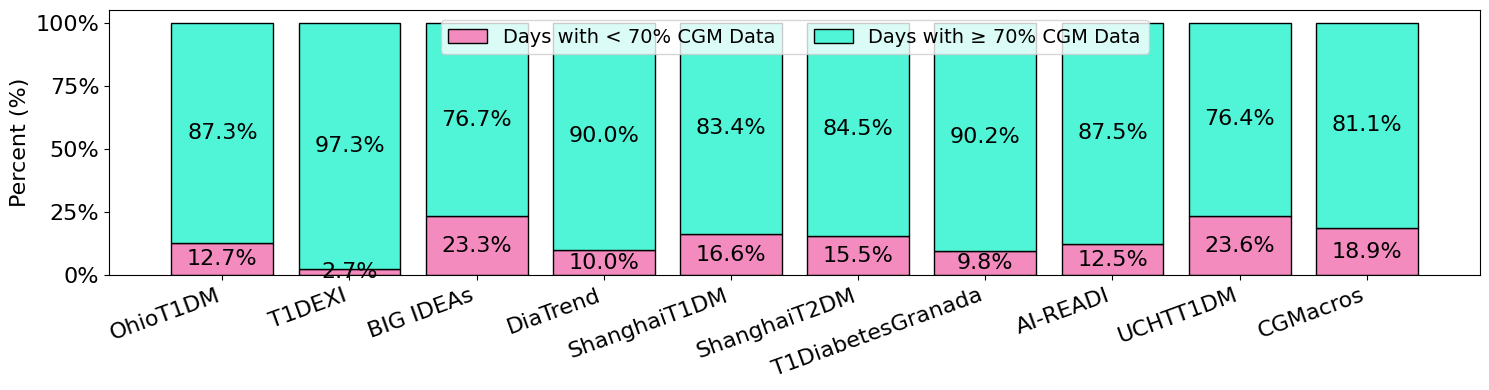

In [98]:
# Example data: each dataset has two parts — <70% and >=70% coverage ratios
from matplotlib.ticker import PercentFormatter
datasets = ['OhioT1DM', 'T1DEXI', 'BIG IDEAs', 'DiaTrend','ShanghaiT1DM','ShanghaiT2DM',
            'T1DiabetesGranada','AI-READI' , 'UCHTT1DM', 'CGMacros']
high_coverage_ratios = [valid_ratio_ohio, 
                        valid_ratio_t1dexi, 
                        valid_ratio_bil,
                        valid_ratio_diatrend,
                        valid_ratio_shanghait1, 
                        valid_ratio_shanghait2,
                        valid_ratio_T1DiabetesGranada, 
                        valid_ratio_aireadi,
                        valid_ratio_uchtt1dm, 
                        valid_ratio_CGMacros]
low_coverage_ratios = [invalid_ratio_ohio, 
                       invalid_ratio_t1dexi, 
                       invalid_ratio_bil, 
                       invalid_ratio_diatrend,
                       invalid_ratio_shanghait1,
                       invalid_ratio_shanghait2,
                       invalid_ratio_T1DiabetesGranada, 
                       invalid_ratio_aireadi,
                       invalid_ratio_uchtt1dm,
                       invalid_ratio_CGMacros
                       ]

# Plot setup
fig, ax = plt.subplots(figsize=(15, 4))

# Bottom bar: < 70% coverage
ax.bar(datasets, low_coverage_ratios, label='Days with < 70% CGM Data', color='#F48BBF', edgecolor='black')

# Top bar: ≥ 70% coverage (stacked on top of low coverage)
ax.bar(datasets, high_coverage_ratios, bottom=low_coverage_ratios, label='Days with ≥ 70% CGM Data', color='#4FF5D6', edgecolor='black')

# Add labels and title
ax.set_ylabel('Percent (%)', fontsize=16)
# ax.set_title('Daily CGM Coverage per Dataset', fontsize=14)
ax.set_ylim(0, 1.05)  # So bars don't touch top

# Format y-axis ticks as percentages
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis='y', labelsize=16)  # Increase font size for y-ticks

# Format x-axis ticks with rotation and larger font size
plt.xticks(rotation=20, ha='right', fontsize=16)

# Annotate percentage values on bars
for i in range(len(datasets)):
    ax.text(i, low_coverage_ratios[i] / 2,
            f"{low_coverage_ratios[i] * 100:.1f}%", ha='center', va='center', color='black', fontsize=16)
    ax.text(i, low_coverage_ratios[i] + high_coverage_ratios[i] / 2,
            f"{high_coverage_ratios[i] * 100:.1f}%", ha='center', va='center', color='black', fontsize=16)

ax.legend(fontsize=14, ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1))
plt.tight_layout()
plt.show()